In [53]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow
from tensorflow import keras
from tensorflow.keras import Sequential , regularizers
from tensorflow.keras.layers import Dense , Flatten , Input , Dropout , BatchNormalization
from sklearn.model_selection import train_test_split , KFold , GridSearchCV
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.preprocessing import StandardScaler
from sklearn.inspection import permutation_importance
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.optimizers import Adam
import lightgbm as lgb
from xgboost import XGBRegressor
from catboost import CatBoostRegressor
from sklearn.ensemble import RandomForestRegressor , ExtraTreesRegressor , BaggingRegressor , StackingRegressor 
from sklearn.linear_model import Ridge

In [183]:
import lasio

well_1_las = lasio.read(r"D:\datasets\AGP hackthon - predict rock permeability\WELL_1.las")
well_2_las = lasio.read(r"D:\datasets\AGP hackthon - predict rock permeability\WELL_2.las")
well_3_las = lasio.read(r"D:\datasets\AGP hackthon - predict rock permeability\WELL_3.las")
well_4_las = lasio.read(r"D:\datasets\AGP hackthon - predict rock permeability\WELL_4.las")
well_test_las = lasio.read(r"D:\OneDrive - Indian Institute of Technology Indian School of Mines Dhanbad\Downloads\Test_Data_2.las")

In [3]:
print(well_1_las.well)

Mnemonic  Unit  Value                                                      Description      
--------  ----  -----                                                      -----------      
STRT      m     1499.879                                                                    
STOP      m     2416.379                                                                    
STEP      m     0.0                                                                         
NULL            -999.25                                                                     
COMP                                                                       COMPANY          
WELL            A10                                                        WELL             
FLD                                                                        FIELD            
LOC                                                                        LOCATION         
SRVC                                                                  

In [4]:
print(well_1_las.curves)

Mnemonic     Unit   Value  Description  
--------     ----   -----  -----------  
DEPT         m             DEPTH        
GAMMA        gAPI          Gamma        
PERM         mD            Perm         
POROSITY     m3/m3         Porosity     
RESISTIVITY  ohm.m         Resistivity  
LITH         _             LITH         


In [184]:
well_1_df = well_1_las.df()
well_2_df = well_2_las.df()
well_3_df = well_3_las.df()
well_4_df = well_4_las.df()
test_df = well_test_las.df()

well_1_df.reset_index(inplace=True)      
well_2_df.reset_index(inplace=True)      
well_3_df.reset_index(inplace=True)      
well_4_df.reset_index(inplace=True)      
test_df.reset_index(inplace=True)      

print(well_1_df.shape ,well_2_df.shape ,well_3_df.shape ,well_4_df.shape, test_df.shape  )

(1835, 6) (701, 6) (552, 6) (2524, 6) (5748, 5)


In [6]:
df = pd.concat(
    [well_1_df, well_2_df, well_3_df, well_4_df],
    ignore_index=True
)
df.shape

(5612, 6)

In [185]:
test_df.head()

,DEPT,GAMMA,POROSITY,RESISTIVITY,LITH
0,1902.2873,65.39847,0.00213,0.52259,2.0
1,1902.7873,63.72424,0.00216,0.49934,2.0
2,1903.2873,60.51658,0.00222,0.75043,3.0
3,1903.7873,56.17398,0.00232,1.28660,3.0
4,1904.2873,52.38428,0.00243,1.59704,3.0


In [8]:
df.head()

,DEPT,GAMMA,PERM,POROSITY,RESISTIVITY,LITH
0,1499.879,NaN,NaN,NaN,NaN,NaN
1,1500.129,NaN,NaN,NaN,NaN,NaN
2,1500.629,NaN,NaN,NaN,NaN,NaN
3,1501.129,NaN,NaN,0.002706,NaN,NaN
4,1501.629,78.869453,0.001246,0.002674,0.709644,3.0


# Check the range of Missing values

In [9]:
df[df["RESISTIVITY"].isna()].index.values

array([   0,    1,    2,    3, 1831, 1832, 1833, 1834, 1835, 1836, 2534,
       2535, 2536, 3084, 3085, 3086, 3087, 3088, 3089, 3090, 3091, 5607,
       5608, 5609, 5610, 5611])

In [10]:
df[df["GAMMA"].isna()].index.values

array([   0,    1,    2,    3, 1831, 1832, 1833, 1834, 1835, 1836, 2535,
       2536, 3085, 3086, 3087, 3088, 3089, 3090, 3091, 5607, 5608, 5609,
       5610, 5611])

In [11]:
df[df["POROSITY"].isna()].index.values

array([   0,    1,    2, 1831, 1832, 1833, 1834, 1835, 1836, 2534, 2535,
       2536, 3084, 3085, 3086, 3087, 3088, 3089, 3090, 5607, 5608, 5609,
       5610, 5611])

In [12]:
df[df["LITH"].isna()].index.values

array([   0,    1,    2,    3, 1831, 1832, 1833, 1834, 1835, 1836, 2534,
       2535, 2536, 3084, 3085, 3086, 3087, 3088, 3089, 3090, 3091, 5607,
       5608, 5609, 5610, 5611])

In [13]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5612 entries, 0 to 5611
Data columns (total 6 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   DEPT         5612 non-null   float64
 1   GAMMA        5588 non-null   float64
 2   PERM         5588 non-null   float64
 3   POROSITY     5588 non-null   float64
 4   RESISTIVITY  5586 non-null   float64
 5   LITH         5586 non-null   float64
dtypes: float64(6)
memory usage: 263.2 KB


# Handel NULL/NA values from the DF

In [14]:

# handel lithology na values 
df["LITH"] = df["LITH"].ffill()
df["LITH"] = df["LITH"].bfill()
df["LITH"] = df["LITH"].astype(int)

#handel resistivity , gamma , perm , porosity na values
df = df.set_index("DEPT")
df[["RESISTIVITY" , "GAMMA" , "PERM" , "POROSITY" ]] = df[["RESISTIVITY" , "GAMMA" , "PERM" , "POROSITY" ]].interpolate(method="index")
df[["RESISTIVITY" , "GAMMA" , "PERM" , "POROSITY" ]] = df[["RESISTIVITY" , "GAMMA" , "PERM" , "POROSITY" ]].bfill()
df[["RESISTIVITY" , "GAMMA" , "PERM" , "POROSITY" ]] = df[["RESISTIVITY" , "GAMMA" , "PERM" , "POROSITY" ]].ffill()
df = df.reset_index()


In [15]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5612 entries, 0 to 5611
Data columns (total 6 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   DEPT         5612 non-null   float64
 1   GAMMA        5612 non-null   float64
 2   PERM         5612 non-null   float64
 3   POROSITY     5612 non-null   float64
 4   RESISTIVITY  5612 non-null   float64
 5   LITH         5612 non-null   int64  
dtypes: float64(5), int64(1)
memory usage: 263.2 KB


In [16]:
df.head()

,DEPT,GAMMA,PERM,POROSITY,RESISTIVITY,LITH
0,1499.879,78.869453,0.001246,0.002706,0.709644,3
1,1500.129,78.869453,0.001246,0.002706,0.709644,3
2,1500.629,78.869453,0.001246,0.002706,0.709644,3
3,1501.129,78.869453,0.001246,0.002706,0.709644,3
4,1501.629,78.869453,0.001246,0.002674,0.709644,3


In [17]:
df.isna().sum()

DEPT           0
GAMMA          0
PERM           0
POROSITY       0
RESISTIVITY    0
LITH           0
dtype: int64

In [18]:
(df["RESISTIVITY"] == -999.25).sum()

np.int64(0)

<Axes: >

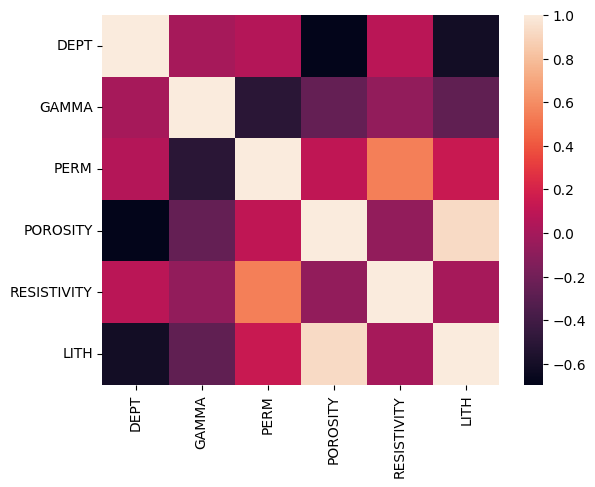

In [19]:
sns.heatmap(df.corr())

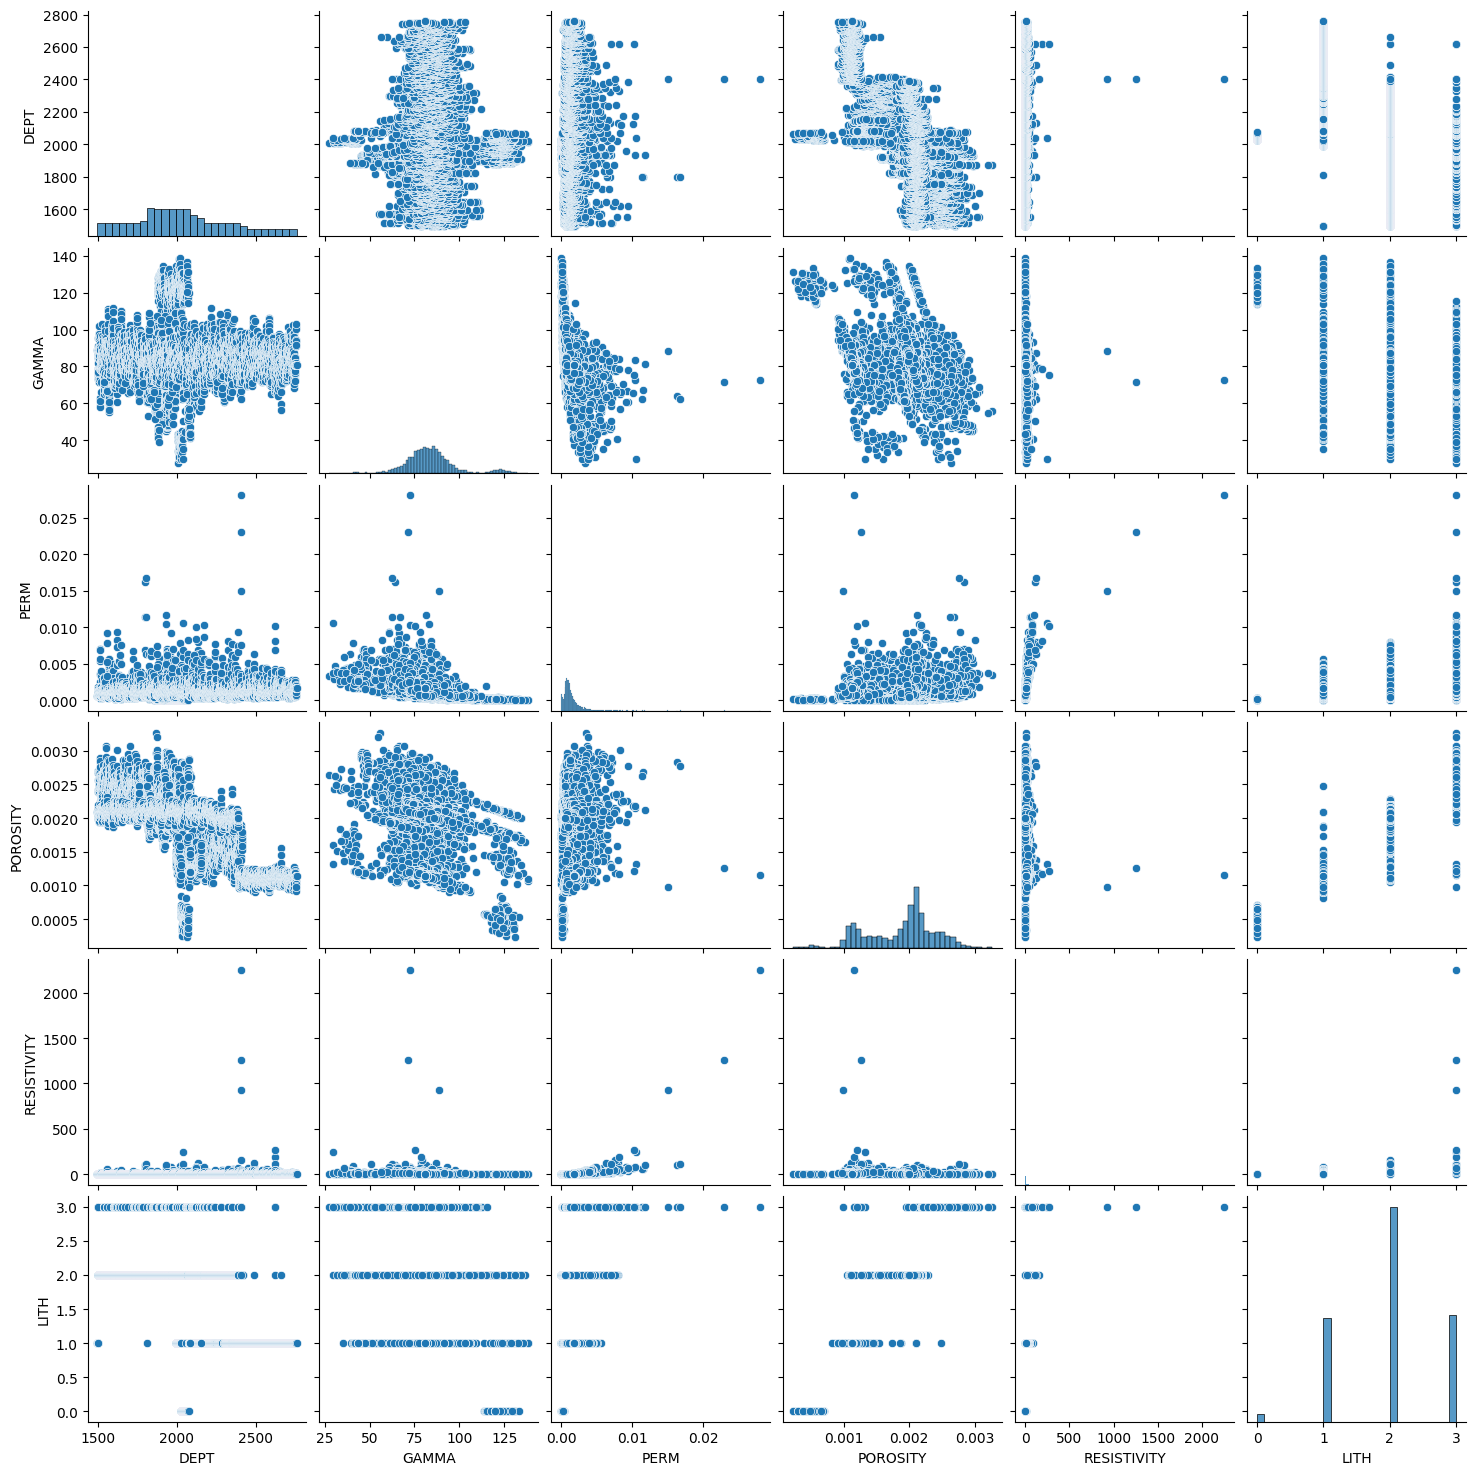

In [20]:
sns.pairplot(df)

# Plot before outliers remove

<Axes: ylabel='PERM'>

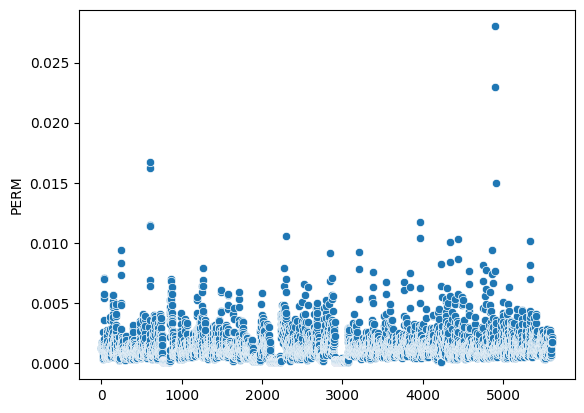

In [21]:
sns.scatterplot(x=df.index.values , y = df["PERM"])

<Axes: ylabel='Density'>

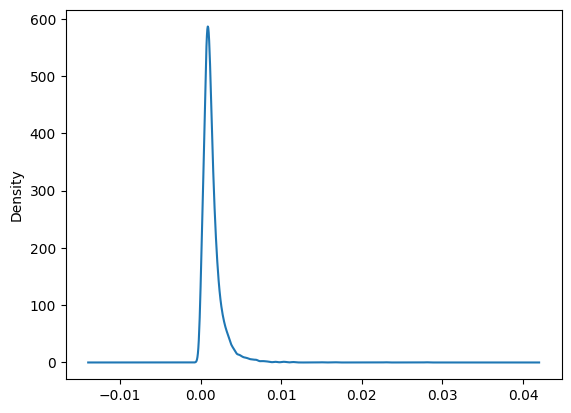

In [22]:
df["PERM"].plot(kind="kde")

<Axes: >

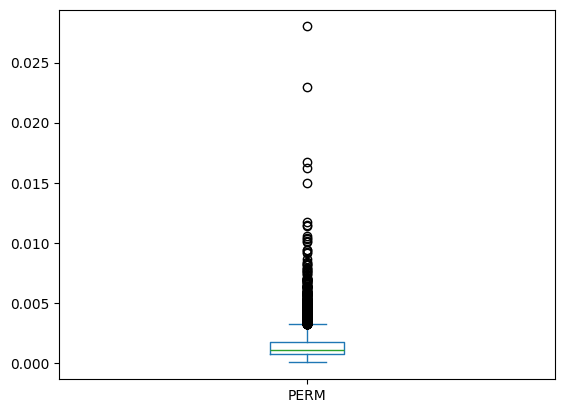

In [23]:
df["PERM"].plot(kind="box")

In [24]:
df["PERM"].describe()

count    5612.000000
mean        0.001410
std         0.001306
min         0.000029
25%         0.000698
50%         0.001089
75%         0.001708
max         0.028008
Name: PERM, dtype: float64

# Remove outliers from permeability

In [25]:
Q1 = df["PERM"].quantile(0.25)
Q3 = df["PERM"].quantile(0.75)
IQR = Q3 - Q1

lower_bound = Q1 - (1.5 * IQR)
upper_bound = Q3 + (1.5 * IQR)

df = df[(df["PERM"] >= lower_bound) & (df["PERM"] <= upper_bound)]


# Plots after removing outliers

<Axes: ylabel='PERM'>

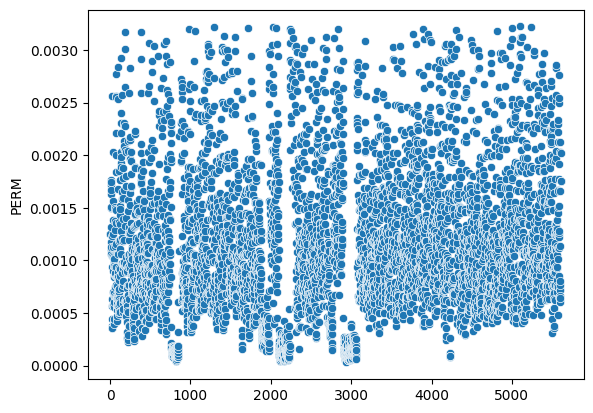

In [26]:
sns.scatterplot(x=df.index.values , y = df["PERM"])

<Axes: ylabel='Density'>

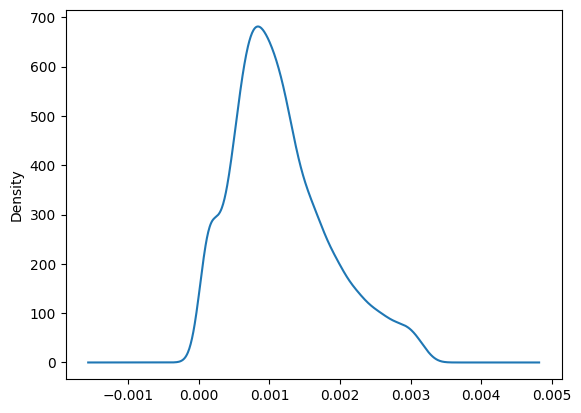

In [27]:
df["PERM"].plot(kind="kde")

<Axes: >

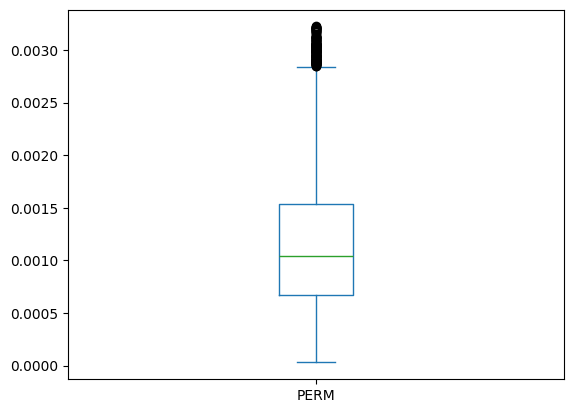

In [28]:
df["PERM"].plot(kind="box")

In [29]:
df["PERM"].describe()

count    5232.000000
mean        0.001158
std         0.000687
min         0.000029
25%         0.000673
50%         0.001039
75%         0.001540
max         0.003222
Name: PERM, dtype: float64

# add more features

In [30]:
df['log_DEPTH'] = np.log(df['DEPT'])

# 2. DEPTH^2
df['DEPTH_squared'] = df['DEPT'] ** 2

# 3. DEPTH / max(DEPTH)
df['DEPTH_normalized'] = df['DEPT'] / df['DEPT'].max()

# 4. Log(GAMMA)
df['log_GAMMA'] = np.log(df['GAMMA'])

# 5. GAMMA^2
df['GAMMA_squared'] = df['GAMMA'] ** 2

# 6. GAMMA / POROSITY
df['GAMMA_to_POROSITY'] = df['GAMMA'] / df['POROSITY']

# 7. Log(RESISTIVITY)
df['log_RESISTIVITY'] = np.log(df['RESISTIVITY'])

# 8. RESISTIVITY^2
df['RESISTIVITY_squared'] = df['RESISTIVITY'] ** 2

# 9. RESISTIVITY / POROSITY
df['RESISTIVITY_to_POROSITY'] = df['RESISTIVITY'] / df['POROSITY']

# Now df has the new features you wanted
print(df.head())

       DEPT      GAMMA      PERM  POROSITY  RESISTIVITY  LITH  log_DEPTH  \
0  1499.879  78.869453  0.001246  0.002706     0.709644     3   7.313140   
1  1500.129  78.869453  0.001246  0.002706     0.709644     3   7.313306   
2  1500.629  78.869453  0.001246  0.002706     0.709644     3   7.313640   
3  1501.129  78.869453  0.001246  0.002706     0.709644     3   7.313973   
4  1501.629  78.869453  0.001246  0.002674     0.709644     3   7.314306   

   DEPTH_squared  DEPTH_normalized  log_GAMMA  GAMMA_squared  \
0   2.249637e+06          0.543857   4.367794    6220.390684   
1   2.250387e+06          0.543947   4.367794    6220.390684   
2   2.251887e+06          0.544129   4.367794    6220.390684   
3   2.253388e+06          0.544310   4.367794    6220.390684   
4   2.254890e+06          0.544491   4.367794    6220.390684   

   GAMMA_to_POROSITY  log_RESISTIVITY  RESISTIVITY_squared  \
0       29141.185693        -0.342991             0.503595   
1       29141.185693        -0.342

C:\Users\Anirban Das\AppData\Local\Temp\ipykernel_10756\3392957191.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['log_DEPTH'] = np.log(df['DEPT'])
C:\Users\Anirban Das\AppData\Local\Temp\ipykernel_10756\3392957191.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['DEPTH_squared'] = df['DEPT'] ** 2
C:\Users\Anirban Das\AppData\Local\Temp\ipykernel_10756\3392957191.py:7: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_ind

# Normalize and Split x_train , x_test , y_train , y_test

In [276]:
# x = df.drop(columns=["PERM"])
x = df[["DEPT"  ,  "GAMMA"  , "POROSITY" , "RESISTIVITY" , "LITH"]]
y = df[["PERM"]]

x_train , x_test , y_train , y_test = train_test_split(x , y , test_size = 0.01 , random_state=1 , shuffle=True)

x_scaler = StandardScaler()
y_scaler = StandardScaler()

x_train_scaled = x_scaler.fit_transform(x_train)
x_test_scaled  = x_scaler.transform(x_test)

y_train_scaled = y_scaler.fit_transform(y_train)
y_test_scaled = y_scaler.transform(y_test)
# y_train_scaled = y_train_scaled.flatten()


In [32]:
x_train_scaled

array([[ 0.36994614, -0.28998927,  0.46433872, ...,  0.4876063 ,
        -0.20455598, -0.22740243],
       [ 1.72283555,  0.42939674, -1.58598035, ...,  2.00408599,
         6.44517652,  6.13245614],
       [-1.2246899 , -0.7573052 ,  1.69083774, ...,  0.01714212,
        -0.24729036, -0.41980868],
       ...,
       [ 0.13629495, -0.12991424,  0.54655786, ...,  0.80279582,
        -0.11009182, -0.04092505],
       [-1.34069853, -0.40164185,  1.21366836, ..., -0.54050405,
        -0.25760717, -0.48040286],
       [ 2.22771819,  0.064297  , -1.50044577, ...,  0.61943757,
        -0.17598191,  0.18428697]], shape=(4185, 14))

# Create Artificial nural network with Regularization and EarlyStopping and BatchNormalization to prevent overfitting , make model stable and quick convergence 

In [33]:
early_stop = EarlyStopping(
    monitor="val_loss",       
    patience=10,              
    min_delta=1e-5,        
    verbose=1,                 
    mode="auto",              
    restore_best_weights=True 
)

In [277]:
model = Sequential()

# model.add(Input(shape=(x_train.shape[1] , )))
# model.add(Dense(32 , activation = "relu" , kernel_regularizer=regularizers.l2(0.01)))
# model.add(BatchNormalization())
# model.add(Dense(32 , activation = "relu" , kernel_regularizer=regularizers.l2(0.01)))
# model.add(BatchNormalization())
# model.add(Dense(32 , activation = "relu" , kernel_regularizer=regularizers.l2(0.01)))
# model.add(Dense(1 , activation = "linear"))

model = Sequential()
model.add(Input(shape=(x_train.shape[1],)))

model.add(Dense(32, activation="relu"))
model.add(BatchNormalization())
# model.add(Dropout(0.1))

model.add(Dense(32, activation="relu"))
model.add(BatchNormalization())
# model.add(Dropout(0.1))

model.add(Dense(32, activation="relu"))
model.add(BatchNormalization())

model.add(Dense(32, activation="relu"))
model.add(BatchNormalization())

model.add(Dense(32, activation="relu"))
model.add(BatchNormalization())

model.add(Dense(32, activation="relu"))
model.add(BatchNormalization())

# model.add(Dense(32, activation="relu", kernel_regularizer=regularizers.l2(0.01)))
# model.add(BatchNormalization())
# # model.add(Dropout(0.05))

model.add(Dense(1, activation="linear"))

In [278]:
model.summary()

Model: "sequential_19"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ dense_48 (Dense)                     │ (None, 32)                  │             192 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_39               │ (None, 32)                  │             128 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_49 (Dense)                     │ (None, 32)                  │           1,056 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_40               │ (None, 32)                  │             128 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_50 (Dense)                     │ (None, 32)                  │           1,056 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_41               │ (None, 32)                  │             128 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_51 (Dense)                     │ (None, 32)                  │           1,056 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_42               │ (None, 32)                  │             128 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_52 (Dense)                     │ (None, 32)                  │           1,056 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_43               │ (None, 32)                  │             128 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_53 (Dense)                     │ (None, 32)                  │           1,056 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_44               │ (None, 32)                  │             128 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_54 (Dense)                     │ (None, 1)                   │              33 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 6,273 (24.50 KB)

 Trainable params: 5,889 (23.00 KB)

 Non-trainable params: 384 (1.50 KB)

In [279]:
# model.compile(optimizer="Adam" , loss = 'mean_squared_error' )
optimizer = Adam(learning_rate=0.0001) 
model.compile(
    loss="mean_absolute_error",
    optimizer=optimizer,
    metrics=["mae"]
)

In [280]:
# history = model.fit(x_train_scaled , y_train_scaled, batch_size=30 , epochs = 600 , verbose=1 , validation_split=0.2,callbacks=[early_stop] )

history = model.fit(
    x_train_scaled,
    y_train_scaled,
    epochs=50,
    batch_size=50,
    validation_split=0.2,
    verbose=1,
)


Epoch 1/50
83/83 ━━━━━━━━━━━━━━━━━━━━ 9s 14ms/step - loss: 1.0853 - mae: 1.0853 - val_loss: 0.7950 - val_mae: 0.7950
Epoch 2/50
83/83 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - loss: 0.7479 - mae: 0.7479 - val_loss: 0.7689 - val_mae: 0.7689
Epoch 3/50
83/83 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - loss: 0.5994 - mae: 0.5994 - val_loss: 0.6698 - val_mae: 0.6698
Epoch 4/50
83/83 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - loss: 0.5278 - mae: 0.5278 - val_loss: 0.5509 - val_mae: 0.5509
Epoch 5/50
83/83 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - loss: 0.4918 - mae: 0.4918 - val_loss: 0.4325 - val_mae: 0.4325
Epoch 6/50
83/83 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - loss: 0.4453 - mae: 0.4453 - val_loss: 0.3474 - val_mae: 0.3474
Epoch 7/50
83/83 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - loss: 0.4315 - mae: 0.4315 - val_loss: 0.3131 - val_mae: 0.3131
Epoch 8/50
83/83 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - loss: 0.3985 - mae: 0.3985 - val_loss: 0.2806 - val_mae: 0.2806
Epoch 9/50
83/83 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - loss: 0.3834 - mae:

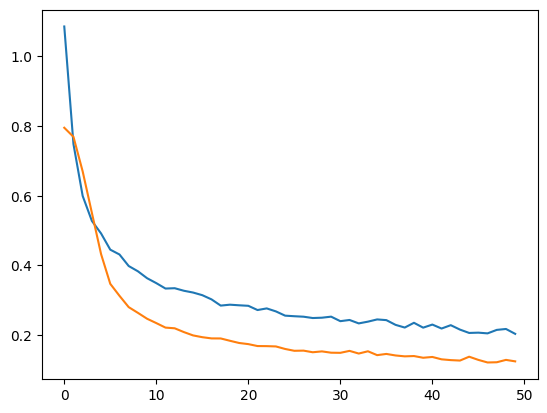

In [281]:
plt.plot(history.history["loss"])
plt.plot(history.history["val_loss"])

In [282]:
y_pred_scaled = model.predict(x_test_scaled)
y_pred = y_scaler.inverse_transform(y_pred_scaled)
# y_pred = y_pred.flatten()

print(r2_score(y_test, y_pred))
print(mean_squared_error(y_test, y_pred))
print(mean_absolute_error(y_test, y_pred))

2/2 ━━━━━━━━━━━━━━━━━━━━ 1s 276ms/step
0.9763588905334473
9.878487361447696e-09
7.843140338081867e-05


In [283]:
test_df_y_pred_scaled = model.predict(test_df_scaled)
test_df_y_pred = y_scaler.inverse_transform(test_df_y_pred_scaled)


submission = pd.DataFrame()
submission['id'] = sample['id']  # must match EXACT name from sample file
submission['target'] = test_df_y_pred  # must match EXACT name from sample file

submission.to_csv("submission.csv", index=False)

180/180 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step


# Predicted permeability vs. Actual permeability plots

In [40]:
y_test.index.values

array([1727, 3707,  846, ..., 2337, 3472, 5011], shape=(1047,))

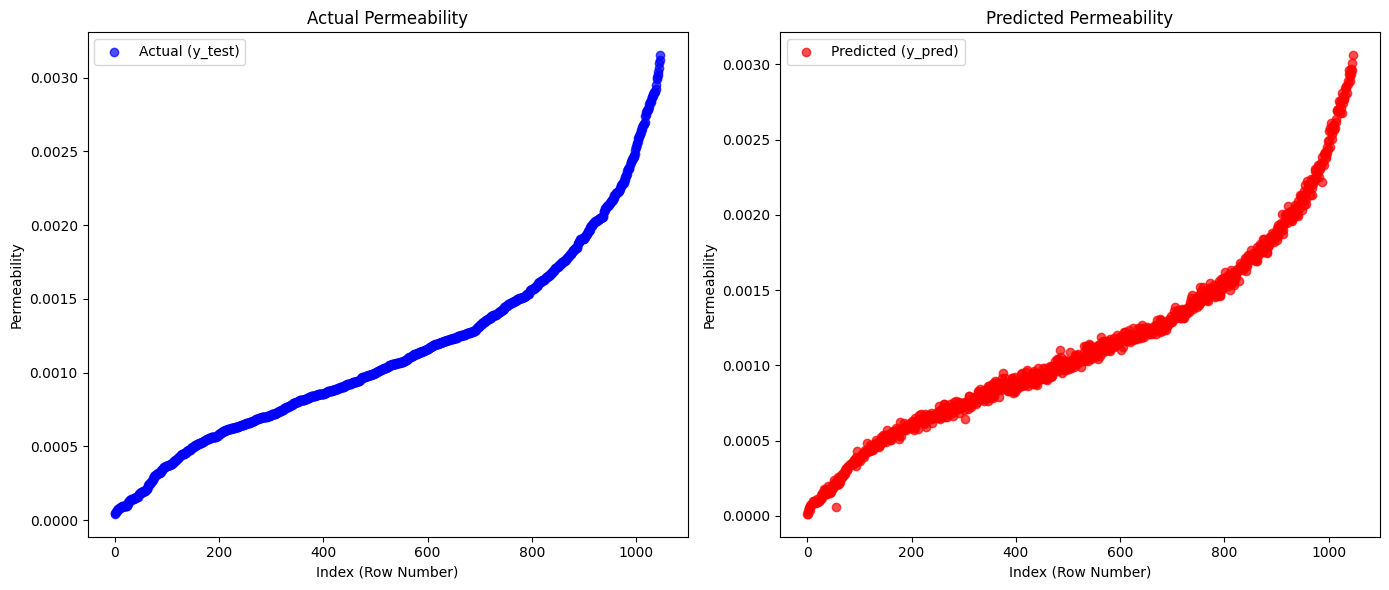

In [41]:
y_pred_flatten = y_pred.flatten()
y_test_flatten = y_test.values.flatten()

plot_df = pd.DataFrame({
    'Actual (y_test)': y_test_flatten,
    'Predicted (y_pred)': y_pred_flatten
})

plot_df = plot_df.sort_values(by="Actual (y_test)")
plot_df.reset_index(inplace = True , drop = True)

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Scatter plot for Actual values (left subplot)
axes[0].scatter(plot_df.index.values, plot_df["Actual (y_test)"], alpha=0.7, color='blue', label='Actual (y_test)')
axes[0].set_title('Actual Permeability')
axes[0].set_xlabel('Index (Row Number)')
axes[0].set_ylabel('Permeability')
axes[0].legend()

# Scatter plot for Predicted values (right subplot)
axes[1].scatter(plot_df.index.values, plot_df["Predicted (y_pred)"], alpha=0.7, color='red', label='Predicted (y_pred)')
axes[1].set_title('Predicted Permeability')
axes[1].set_xlabel('Index (Row Number)')
axes[1].set_ylabel('Permeability')
axes[1].legend()

# Adjust layout to avoid overlapping
plt.tight_layout()

# Show the plots
plt.show()

# Feature importance / sensitivity interpretation

In [42]:

def custom_score(model, X, y):
    y_pred_scaled = model.predict(X)  
    y_pred = y_scaler.inverse_transform(y_pred_scaled)  
    return mean_squared_error(y, y_pred) 

results = permutation_importance(model, x_test_scaled, y_test, scoring=custom_score, n_repeats=10, random_state=42)

importances = results.importances_mean

importances_normalized = (importances - importances.min()) / (importances.max() - importances.min())

feature_importance_df = pd.DataFrame({
    'Feature': x_test.columns, 
    'Normalized Importance': importances_normalized
}).sort_values(by='Normalized Importance', ascending=False)

print(feature_importance_df)



33/33 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step
33/33 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step
33/33 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step
33/33 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step
33/33 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
33/33 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step
33/33 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step
33/33 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step
33/33 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step
33/33 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step
33/33 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
33/33 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step
33/33 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step
33/33 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step
33/33 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step
33/33 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step
33/33 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step
33/33 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step
33/33 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step
33/33 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step
33/33 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step
33/33 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step
33/33 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step
33/33 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step
33/33 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step
33/33 ━━━━━━━━━━━━━━━━━━━

In [43]:
results

{'importances_mean': array([-5.87380937e-09, -9.20676968e-09, -1.33372996e-07, -2.84353662e-07,
        -3.92847255e-09, -9.29481649e-09, -9.92789266e-09, -1.45158689e-08,
        -1.24924032e-08, -5.73790133e-09, -1.86143245e-08, -4.99504663e-07,
        -4.08922982e-09, -2.96387985e-08]),
 'importances_std': array([7.50035874e-10, 6.10983868e-10, 5.13877007e-09, 1.29279000e-08,
        3.38631557e-10, 3.77937479e-10, 4.52442842e-10, 7.30524979e-10,
        5.77363848e-10, 3.67950394e-10, 2.76720738e-09, 1.35949374e-08,
        8.62745789e-10, 1.16832693e-09]),
 'importances': array([[-5.72685421e-09, -4.82317752e-09, -5.59764424e-09,
         -7.23759774e-09, -6.21444463e-09, -5.28709132e-09,
         -5.34839029e-09, -7.18920179e-09, -5.61690838e-09,
         -5.69678360e-09],
        [-9.80709347e-09, -9.37132827e-09, -8.92958296e-09,
         -9.71742564e-09, -8.54476989e-09, -1.00782419e-08,
         -9.33820099e-09, -7.86889454e-09, -9.16702769e-09,
         -9.24513144e-09],
  

# Handel NULL/NA values from the Test DF

In [186]:

# handel lithology na values 
test_df["LITH"] = test_df["LITH"].ffill()
test_df["LITH"] = test_df["LITH"].bfill()
test_df["LITH"] = test_df["LITH"].astype(int)

#handel resistivity , gamma , perm , porosity na values
test_df = test_df.set_index("DEPT")
test_df[["RESISTIVITY" , "GAMMA" , "POROSITY" ]] = test_df[["RESISTIVITY" , "GAMMA" , "POROSITY" ]].interpolate(method="index")
test_df[["RESISTIVITY" , "GAMMA" , "POROSITY" ]] = test_df[["RESISTIVITY" , "GAMMA" , "POROSITY" ]].bfill()
test_df[["RESISTIVITY" , "GAMMA" , "POROSITY" ]] = test_df[["RESISTIVITY" , "GAMMA" , "POROSITY" ]].ffill()
test_df = test_df.reset_index()


In [189]:
test_df.head()

,DEPT,GAMMA,POROSITY,RESISTIVITY,LITH
0,1902.2873,65.39847,0.00213,0.52259,2
1,1902.7873,63.72424,0.00216,0.49934,2
2,1903.2873,60.51658,0.00222,0.75043,3
3,1903.7873,56.17398,0.00232,1.28660,3
4,1904.2873,52.38428,0.00243,1.59704,3


In [190]:
test_df.isna().sum()

DEPT           0
GAMMA          0
POROSITY       0
RESISTIVITY    0
LITH           0
dtype: int64

In [192]:
test_df = test_df[["DEPT"  ,  "GAMMA"  , "POROSITY" , "RESISTIVITY" , "LITH"]]
test_df_scaled  = x_scaler.transform(test_df)

In [193]:
test_df_y_pred_scaled = model.predict(test_df_scaled)
test_df_y_pred = y_scaler.inverse_transform(y_pred_scaled)

InvalidArgumentError: Graph execution error:

Detected at node sequential_1_1/dense_1/Relu defined at (most recent call last):
  File "C:\Users\Anirban Das\AppData\Local\Programs\Python\Python310\lib\runpy.py", line 196, in _run_module_as_main

  File "C:\Users\Anirban Das\AppData\Local\Programs\Python\Python310\lib\runpy.py", line 86, in _run_code

  File "C:\Users\Anirban Das\AppData\Local\Programs\Python\Python310\lib\site-packages\ipykernel_launcher.py", line 18, in <module>

  File "C:\Users\Anirban Das\AppData\Local\Programs\Python\Python310\lib\site-packages\traitlets\config\application.py", line 1075, in launch_instance

  File "C:\Users\Anirban Das\AppData\Local\Programs\Python\Python310\lib\site-packages\ipykernel\kernelapp.py", line 758, in start

  File "C:\Users\Anirban Das\AppData\Local\Programs\Python\Python310\lib\site-packages\tornado\platform\asyncio.py", line 211, in start

  File "C:\Users\Anirban Das\AppData\Local\Programs\Python\Python310\lib\asyncio\base_events.p

In [ ]:
test_df_y_pred

In [ ]:
submission = pd.DataFrame({
    'id': test_df.index.values + 1,  # Replace 'id' with your test data's ID column
    'Permeability': test_df_y_pred.flatten()  # Ensure predictions are in the correct shape
})

In [ ]:
submission.to_csv('submission.csv', index=False)

# using ensemble of different models

In [194]:
xgb_model1 = XGBRegressor(
    objective='reg:absoluteerror',
    n_estimators=1000,
    learning_rate=0.07,
    max_depth=6,
    random_state=42
)

# xgb_model2 = XGBRegressor(
#     objective='reg:squarederror',
#     n_estimators=1000,
#     learning_rate=0.0001,
#     max_depth=6,
#     random_state=42
# )

# cat_model = CatBoostRegressor(
#     iterations=1000,
#     learning_rate=0.05,
#     depth=4,
#     verbose=0,
#     random_state=42
# )

rf_model1 = RandomForestRegressor(
    n_estimators=1000,
    max_depth=15,
    random_state=42,
    n_jobs=-1,
    max_samples=0.7,
    max_features=0.9,
)
rf_model2 = RandomForestRegressor(
    n_estimators=1000,
    max_depth=10,
    random_state=1,
    n_jobs=-1,
    max_samples=0.9,
    max_features=0.7,
)
rf_model3 = RandomForestRegressor(
    n_estimators=1000,
    max_depth=10,
    random_state=1,
    n_jobs=-1,
    max_samples=0.9,
    max_features=0.7,
)
rf_model4 = RandomForestRegressor(
    n_estimators=1500,
    max_depth=15,
    random_state=1,
    n_jobs=-1,
    max_samples=0.9,
    max_features=0.7,
)
rf_model5 = RandomForestRegressor(
    n_estimators=880,
    max_depth=12,
    random_state=1,
    n_jobs=-1,
    max_samples=0.9,
    max_features=0.7,
)


In [195]:
xgb_model1.fit(x_train_scaled, y_train.values.flatten())
# xgb_model2.fit(x_train_scaled, y_train.values.flatten())
cat_model.fit(x_train_scaled, y_train.values.flatten())
rf_model1.fit(x_train_scaled, y_train.values.flatten())
rf_model2.fit(x_train_scaled, y_train.values.flatten())
# rf_model3.fit(x_train_scaled, y_train.values.flatten())
# rf_model4.fit(x_train_scaled, y_train.values.flatten())
# rf_model5.fit(x_train_scaled, y_train.values.flatten())

,n_estimators,1000
,criterion,'squared_error'
,max_depth,10
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,0.7
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [196]:
pred_xgb1_train = xgb_model1.predict(x_train_scaled)
# pred_xgb2_train = xgb_model2.predict(x_train_scaled)
pred_cat_train = cat_model.predict(x_train_scaled)
pred_rf1_train = rf_model1.predict(x_train_scaled)
pred_rf2_train = rf_model2.predict(x_train_scaled)
# pred_rf3_train = rf_model2.predict(x_train_scaled)
# pred_rf4_train = rf_model2.predict(x_train_scaled)
# pred_rf5_train = rf_model2.predict(x_train_scaled)

pred_xgb1 = xgb_model1.predict(x_test_scaled)
# pred_xgb2 = xgb_model2.predict(x_test_scaled)
pred_cat = cat_model.predict(x_test_scaled)
pred_rf1 = rf_model1.predict(x_test_scaled)
pred_rf2 = rf_model2.predict(x_test_scaled)
# pred_rf3 = rf_model2.predict(x_test_scaled)
# pred_rf4 = rf_model2.predict(x_test_scaled)
# pred_rf5 = rf_model2.predict(x_test_scaled)

test_pred_xgb1 = xgb_model1.predict(test_df_scaled)
# pred_xgb2 = xgb_model2.predict(test_df_scaled)
test_pred_cat = cat_model.predict(test_df_scaled)
test_pred_rf1 = rf_model1.predict(test_df_scaled)
test_pred_rf2 = rf_model2.predict(test_df_scaled)

In [197]:
stack_X_train = np.column_stack((pred_xgb1_train, 
                                 # pred_xgb2_train , 
                                 pred_cat_train,
                                 pred_rf1_train,
                                 pred_rf2_train,
                                 # pred_rf3_train,
                                 # pred_rf4_train,
                                 # pred_rf5_train
                                ))
stack_X_test = np.column_stack((pred_xgb1, 
                                # pred_xgb2, 
                                pred_cat, 
                                pred_rf1,
                                pred_rf2,
                                # pred_rf3,
                                # pred_rf4,
                                # pred_rf5
                               ))
test_stack_X_test = np.column_stack((test_pred_xgb1, 
                                # pred_xgb2, 
                                test_pred_cat, 
                                test_pred_rf1,
                                test_pred_rf2,
                                # pred_rf3,
                                # pred_rf4,
                                # pred_rf5
                               ))

In [198]:
meta_model_rf = RandomForestRegressor(
    # criterion="absolute_error",
    max_depth=20,
    max_samples=0.8,
    max_features=0.8,
    n_estimators=1500,
    n_jobs=-1,
    oob_score=True,
    verbose=1,
    random_state=42
)
# meta_model_rf = XGBRegressor(
#     objective='reg:absoluteerror',
#     n_estimators=1000,
#     learning_rate=0.01,
#     max_depth=15,
#     random_state=42
# )


meta_model_rf.fit(stack_X_train, y_train.values.flatten())

# FINAL PREDICTIONS
stacked_pred_rf = meta_model_rf.predict(stack_X_test)



[Parallel(n_jobs=-1)]: Using backend ThreadingBackend with 12 concurrent workers.
[Parallel(n_jobs=-1)]: Done  26 tasks      | elapsed:    0.2s
[Parallel(n_jobs=-1)]: Done 176 tasks      | elapsed:    1.6s
[Parallel(n_jobs=-1)]: Done 426 tasks      | elapsed:    3.8s
[Parallel(n_jobs=-1)]: Done 776 tasks      | elapsed:    6.9s
[Parallel(n_jobs=-1)]: Done 1226 tasks      | elapsed:   10.9s
[Parallel(n_jobs=-1)]: Done 1500 out of 1500 | elapsed:   13.3s finished
[Parallel(n_jobs=12)]: Using backend ThreadingBackend with 12 concurrent workers.
[Parallel(n_jobs=12)]: Done  26 tasks      | elapsed:    0.0s
[Parallel(n_jobs=12)]: Done 176 tasks      | elapsed:    0.0s
[Parallel(n_jobs=12)]: Done 426 tasks      | elapsed:    0.1s
[Parallel(n_jobs=12)]: Done 776 tasks      | elapsed:    0.2s
[Parallel(n_jobs=12)]: Done 1226 tasks      | elapsed:    0.4s
[Parallel(n_jobs=12)]: Done 1500 out of 1500 | elapsed:    0.6s finished


In [202]:
stacked_pred_rf

array([0.00030708, 0.0015732 , 0.0001723 , ..., 0.00195797, 0.00125631,
       0.0004673 ], shape=(1047,))

In [203]:
y_test

,PERM
1727,0.000284
3707,0.001583
846,0.000182
33,0.002026
1026,0.000372
...,...
3713,0.000749
2672,0.001029
2337,0.001967
3472,0.001257


In [199]:
stacked_mse_rf = mean_squared_error(y_test, stacked_pred_rf)
stacked_r2_rf = r2_score(y_test, stacked_pred_rf)

print("MSE",  mean_squared_error(y_test, stacked_pred_rf))
print("RMSE",  np.sqrt(mean_squared_error(y_test, stacked_pred_rf)))
print("R2",  r2_score(y_test, stacked_pred_rf))
print("MAE",  mean_absolute_error(y_test , stacked_pred_rf))


MSE 4.0989347742873984e-10
RMSE 2.0245826173034773e-05
R2 0.9990652451461316
MAE 1.0368676290352675e-05


# predict for given test dataset

In [200]:
test_df_y_pred = meta_model_rf.predict(test_stack_X_test)
# test_df_y_pred = y_scaler.inverse_transform(y_pred_scaled)

[Parallel(n_jobs=12)]: Using backend ThreadingBackend with 12 concurrent workers.
[Parallel(n_jobs=12)]: Done  26 tasks      | elapsed:    0.0s
[Parallel(n_jobs=12)]: Done 176 tasks      | elapsed:    0.3s
[Parallel(n_jobs=12)]: Done 426 tasks      | elapsed:    0.7s
[Parallel(n_jobs=12)]: Done 776 tasks      | elapsed:    1.4s
[Parallel(n_jobs=12)]: Done 1226 tasks      | elapsed:    2.2s
[Parallel(n_jobs=12)]: Done 1500 out of 1500 | elapsed:    2.7s finished


In [206]:
test_df_y_pred.shape

(5748,)

In [211]:
sample = pd.read_csv(r"D:\OneDrive - Indian Institute of Technology Indian School of Mines Dhanbad\Downloads\sample_submission.csv")

In [214]:
submission = pd.DataFrame()
submission['id'] = sample['id']  # must match EXACT name from sample file
submission['target'] = test_df_y_pred  # must match EXACT name from sample file

submission.to_csv("submission.csv", index=False)

# using multi layer stacking

In [ ]:
# y_train = y_train.values
y_train = y_train.flatten()

In [ ]:
y_train

In [ ]:
kf = KFold(n_splits=5, shuffle=True, random_state=42)

In [ ]:
layer1_models = []

# 32 XGBoost models with different hyperparameters
for depth in [3, 4 ]:
    for lr in [0.01, 0.05]:
        layer1_models.append(
            XGBRegressor(
                max_depth=depth,
                learning_rate=lr,
                n_estimators=300,
                objective="reg:squarederror",
                random_state=42
            )
        )

# 16 RandomForest models
for d in [14, 6]:
    layer1_models.append(
        RandomForestRegressor(
            n_estimators=300,
            max_depth=d,
            random_state=42
        )
    )

# 16 ExtraTrees models
for d in [ 8, 10]:
    layer1_models.append(
        ExtraTreesRegressor(
            n_estimators=300,
            max_depth=d,
            random_state=42
        )
    )

# ensure exactly 64 models
layer1_models = layer1_models[:64]

# OOF predictions for layer 1
layer1_oof = np.zeros((len(x_train_scaled), len(layer1_models)))

print("Training Layer 1 (64 models)...")

for i, model in enumerate(layer1_models):
    fold = 0
    for train_idx, val_idx in kf.split(x_train_scaled):
        model.fit(x_train_scaled[train_idx], y_train[train_idx])
        preds = model.predict(x_train_scaled[val_idx])
        layer1_oof[val_idx, i] = preds
        fold += 1

print("Layer 1 complete.")

In [ ]:
# ------------------------------------------------------------
# LAYER 2 → 16 models trained on layer 1 OOF features
# ------------------------------------------------------------
layer2_models = [
    XGBRegressor(max_depth=4, learning_rate=0.05, n_estimators=200, objective="reg:squarederror"),
    CatBoostRegressor(iterations=300, learning_rate=0.05, depth=6, verbose=0),
    RandomForestRegressor(n_estimators=200, random_state=42),
    ExtraTreesRegressor(n_estimators=200, random_state=42)
] * 4  # total = 16 models

layer2_oof = np.zeros((len(x_train_scaled), len(layer2_models)))

print("Training Layer 2 (16 models)...")

for i, model in enumerate(layer2_models):
    for train_idx, val_idx in kf.split(layer1_oof):
        model.fit(layer1_oof[train_idx], y_train[train_idx])
        preds = model.predict(layer1_oof[val_idx])
        layer2_oof[val_idx, i] = preds

print("Layer 2 complete.")

In [ ]:
print("Training Layer 3 (Final model)...")

final_model = Ridge(alpha=1.0)
final_model.fit(layer2_oof, y_train)

# TRAIN PREDICTIONS
train_pred = final_model.predict(layer2_oof)

In [ ]:
# TRAIN PREDICTIONS
train_pred = final_model.predict(layer2_oof)


In [ ]:
# FINAL METRICS ON TRAIN
mae_train = mean_absolute_error(y_train, train_pred)
rmse_train = np.sqrt(mean_squared_error(y_train, train_pred))
r2_train = r2_score(y_train, train_pred)

print("===== FINAL STACKING MODEL RESULTS (TRAIN) =====")
print(f"MAE:  {mae_train}")
print(f"RMSE: {rmse_train}")
print(f"R²:   {r2_train}")
print("================================================")

# using single xgboost

In [284]:
xgb_model = XGBRegressor(
    objective='reg:absoluteerror',
    n_estimators=1500,
    learning_rate=0.001,
    max_depth=6,
    random_state=42
)

# ----------------------------------------------------------
# 2. Train Model
# (Use X_train_scaled if you pre-scaled your inputs)
# ----------------------------------------------------------
xgb_model.fit(x_train_scaled, y_train)


,objective,'reg:absoluteerror'
,base_score,None
,booster,None
,callbacks,None
,colsample_bylevel,None
,colsample_bynode,None
,colsample_bytree,None
,device,None
,early_stopping_rounds,None
,enable_categorical,False
,eval_metric,None


In [285]:
param_grid = {
    'n_estimators': [100, 200, 300],  # Number of boosting rounds
    'learning_rate': [0.01, 0.05, 0.1],  # Learning rate
    'max_depth': [3, 5, 7],  # Maximum depth of a tree
    'subsample': [0.7, 0.8, 1.0],  # Fraction of samples used for training
    'colsample_bytree': [0.7, 0.8, 1.0],  # Fraction of features used for each tree
    'gamma': [0, 0.1, 0.2]  # Minimum loss reduction required to make a further partition
}
grid_search = GridSearchCV(estimator=XGBRegressor(), param_grid=param_grid, cv=3, n_jobs=-1, verbose=2, scoring='neg_mean_absolute_error')

# Fit grid search
grid_search.fit(x_train_scaled, y_train)

# Get best parameters
print("Best Parameters: ", grid_search.best_params_)

Fitting 3 folds for each of 729 candidates, totalling 2187 fits
Best Parameters:  {'colsample_bytree': 1.0, 'gamma': 0, 'learning_rate': 0.05, 'max_depth': 7, 'n_estimators': 100, 'subsample': 1.0}


In [286]:
best_model = grid_search.best_estimator_

# Predictions
y_pred = best_model.predict(x_test_scaled)

# Evaluate the model
mse = mean_squared_error(y_test, y_pred)
print("Mean Squared Error: ", mse)
print(mean_absolute_error(y_test, y_pred))

Mean Squared Error:  3.773319434685618e-09
3.681722955661826e-05


In [289]:

# ----------------------------------------------------------
# 3. Predictions
# ----------------------------------------------------------
y_pred = xgb_model.predict(x_test_scaled)

# ----------------------------------------------------------
# 4. Evaluation Metrics
# ----------------------------------------------------------
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print("========== XGBoost Ultra-Low-MAE Model ==========")
print(f"MAE:  {mae}")
print(f"RMSE: {rmse}")
print(f"R²:   {r2}")
print("=================================================")

========== XGBoost Ultra-Low-MAE Model ==========
MAE:  0.00012624679948203266
RMSE: 0.00029094769042350385
R²:   0.7974152565002441


In [290]:
test_df_y_pred = xgb_model.predict(test_df_scaled)

submission = pd.DataFrame()
submission['id'] = sample['id']  # must match EXACT name from sample file
submission['target'] =  test_df_y_pred  # must match EXACT name from sample file

submission.to_csv("submission.csv", index=False)

# using bagging with xgboost

In [ ]:
xgb_model = XGBRegressor(
    objective='reg:squarederror',
    n_estimators=200,
    learning_rate=0.05,
    max_depth=6,
    random_state=42
)

bag_xgb = BaggingRegressor(
    estimator=xgb_model,
    n_estimators=500,          # 10 XGBoost models = strong bagging
    max_samples=0.7,          # 70% bootstrap sample for each model
    max_features=0.7,         # use all features
    bootstrap=True,
    n_jobs=-1,
    random_state=42
)

bag_xgb.fit(x_train_scaled, y_train.values.flatten())

In [ ]:
y_pred = bag_xgb.predict(x_test_scaled)

# ----------------------------------------------------------
# Evaluate
# ----------------------------------------------------------
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print("============= Bagged XGBoost Model =============")
print(f"MAE :  {mae}")
print(f"RMSE:  {rmse}")
print(f"R²  :  {r2}")
print("================================================")

# try with mode model ensembling

In [ ]:
base_models = [
    ('xgb', XGBRegressor(objective='reg:squarederror', n_estimators=500, learning_rate=0.05, max_depth=6, random_state=42)),
    ('catboost', CatBoostRegressor(iterations=500, learning_rate=0.05, depth=6, verbose=0, random_state=42)),
    ('rf', RandomForestRegressor(n_estimators=500, max_depth=None, random_state=42)),
    ('lgb', lgb.LGBMRegressor(n_estimators=500, learning_rate=0.05, max_depth=6, random_state=42))
]

meta_model = XGBRegressor(objective='reg:squarederror', n_estimators=500, learning_rate=0.05, max_depth=6, random_state=42)

# Create the Stacking Regressor
stacking_model = StackingRegressor(estimators=base_models, final_estimator=meta_model)

# Fit the model
stacking_model.fit(x_train_scaled, y_train.values.flatten())

In [ ]:
y_pred = stacking_model.predict(x_test_scaled)

# Calculate MAE (Mean Absolute Error)


In [ ]:
mae = mean_absolute_error(y_test, y_pred)
print(f'Mean Absolute Error (MAE): {mae}')
print(r2_score(y_test , y_pred))